# 04 — Area-level garbage forecasting

Compact notebook for the geographic extension of the garbage-report forecasting project.

**Selected model**

\[
\text{reports} \sim \text{area} + \text{trend} + \text{weekday} + \text{month} + \text{holiday} + \text{recent 7-day activity}
\]

The model is a shared **Poisson GLM** across all areas. `recent7_avg` uses only the previous 7 actual days in the same area, so the validation below is **rolling one-day-ahead**.

This notebook keeps only the results needed to justify and diagnose the final area-level model; the earlier exploratory experiments do not need to remain here.


In [1]:
from pathlib import Path
import sys
import holidays
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works whether Jupyter was launched from the project root or notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT.resolve()))

from src.area_forecasting import (
    AREA_FORMULA,
    NO_TREND_FORMULA,
    prepare_area_panel,
    area_sparsity_profile,
    fit_area_poisson,
    evaluate_area_model,
    poisson_dispersion,
    zero_calibration,
    residual_autocorrelation,
    calibration_table,
)
#from src.area_mapping import map_requests_to_areas
DATA_PATH = PROJECT_ROOT / "data" / "mapped_requests.csv"
TEST_YEARS = [2023, 2024, 2025]


## 1. Load data and build the area-day panel

In [2]:
df = pd.read_csv(DATA_PATH)
df['reported'] = pd.to_datetime(df['reported'])
df2026 = pd.read_csv('data/2026requests.csv')
df2026['reported'] = pd.to_datetime(df2026['reported'])
garbage_mask = (
    pd.to_datetime(df["reported"], errors="coerce").dt.year.between(2020, 2025)
    & df["issue"].eq("garbage")
)

garbage_rows = df.loc[garbage_mask]

print(f"Garbage reports:        {len(garbage_rows):,}")
print(f"Missing area_name:      {garbage_rows['area_name'].isna().sum():,}")
print(f"Missing area percentage:{100 * garbage_rows['area_name'].isna().mean():.2f}%")

panel = prepare_area_panel(df)

print(f"Areas:                  {panel['area_name'].nunique()}")
print(f"Area-day observations:  {len(panel):,}")
print(f"Date range:              {panel['date'].min().date()} -> {panel['date'].max().date()}")


Garbage reports:        45,621
Missing area_name:      274
Missing area percentage:0.60%
Areas:                  84
Area-day observations:  184,044
Date range:              2020-01-02 -> 2025-12-31


## 2. Compact sparsity check

This replaces the larger `mappedEDA.ipynb`. We only keep the main facts needed for modeling: how active each area is and how often its daily count is zero.


,areas,pct_of_areas
sparsity_band,,
<50% zero days,2,2.38
50–75% zero days,15,17.86
75–90% zero days,36,42.86
90–95% zero days,15,17.86
>95% zero days,16,19.05


Median zero-day percentage: 86.99%
Median reports/day:          0.154


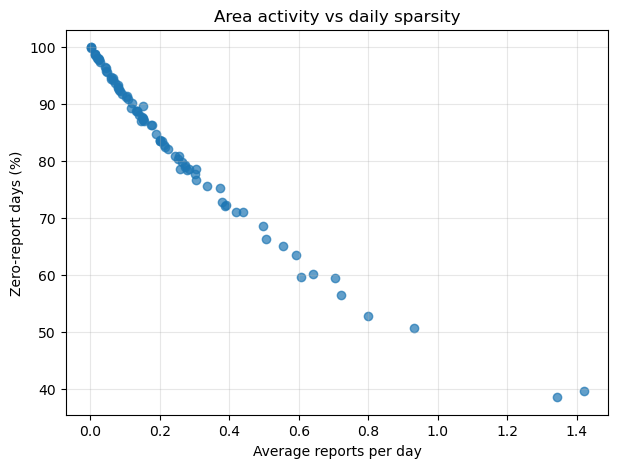

In [3]:
area_profile = area_sparsity_profile(panel)

bins = [0, 50, 75, 90, 95, 100]
labels = [
    "<50% zero days",
    "50–75% zero days",
    "75–90% zero days",
    "90–95% zero days",
    ">95% zero days",
]

area_profile["sparsity_band"] = pd.cut(
    area_profile["zero_day_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

sparsity_summary = (
    area_profile["sparsity_band"]
    .value_counts(sort=False)
    .rename("areas")
    .to_frame()
)
sparsity_summary["pct_of_areas"] = 100 * sparsity_summary["areas"] / len(area_profile)

display(sparsity_summary.round(2))

print(f"Median zero-day percentage: {area_profile['zero_day_pct'].median():.2f}%")
print(f"Median reports/day:          {area_profile['avg_reports_per_day'].median():.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(
    area_profile["avg_reports_per_day"],
    area_profile["zero_day_pct"],
    alpha=0.7,
)
plt.xlabel("Average reports per day")
plt.ylabel("Zero-report days (%)")
plt.title("Area activity vs daily sparsity")
plt.grid(alpha=0.3)
plt.show()


## 3. Final model choice: no trend vs trend

The no-trend model has slightly better raw MAE because most area-days are zero. The trend model is retained because it is much less biased, improves RMSE / Poisson deviance, and performs better on active days — a better fit for operational workload planning.


In [ ]:
comparison_rows = []

for name, formula in {
    "no_trend": NO_TREND_FORMULA,
    "with_trend": AREA_FORMULA,
}.items():
    metrics, _ = evaluate_area_model(
        panel,
        formula=formula,
        test_years=TEST_YEARS,
    )

    row = metrics[
        [
            "MAE",
            "RMSE",
            "Poisson_deviance",
            "zero_day_MAE",
            "active_day_MAE",
            "mean_error",
            "mean_actual",
            "mean_predicted",
            "expected_zero_pct",
            "observed_zero_pct",
        ]
    ].mean()

    row.name = name
    comparison_rows.append(row)

model_comparison = pd.DataFrame(comparison_rows)
display(model_comparison.round(4))


## 4. Fit the selected model and check dispersion

In [ ]:
selected_model = fit_area_poisson(panel, formula=NO_TREND_FORMULA)

print(f"AIC: {selected_model.aic:.2f}")
display(poisson_dispersion(selected_model).to_frame("value").round(3))


AIC: 189761.99


,value
pearson_dispersion,1.335
deviance_per_df,0.658


## 5. Chronological out-of-sample performance

In [ ]:
metrics, oos = evaluate_area_model(
    panel,
    formula=NO_TREND_FORMULA,
    test_years=TEST_YEARS,
)

display(metrics.round(4))

print("Average:")
display(
    metrics[
        [
            "MAE",
            "RMSE",
            "Poisson_deviance",
            "zero_day_MAE",
            "active_day_MAE",
            "mean_error",
        ]
    ].mean().to_frame("mean").T.round(4)
)


,year,MAE,RMSE,Poisson_deviance,zero_day_MAE,active_day_MAE,mean_error,mean_actual,mean_predicted,observed_zero_pct,expected_zero_pct
0,2023,0.3190,0.6297,0.7213,0.1480,1.0638,0.0715,0.2785,0.2070,81.3275,83.9047
1,2024,0.3278,0.6361,0.7135,0.1638,1.0407,0.0506,0.2775,0.2268,81.3004,82.7243
2,2025,0.3609,0.7345,0.7825,0.1673,1.1094,0.0799,0.3291,0.2492,79.4488,81.6003


Average:


,MAE,RMSE,Poisson_deviance,zero_day_MAE,active_day_MAE,mean_error
mean,0.3359,0.6668,0.7391,0.1597,1.0713,0.0674


## 6. Zero calibration and residual autocorrelation

In [ ]:
print("Zero calibration:")
display(zero_calibration(oos).to_frame("value").round(3))

print("\nResidual autocorrelation by area:")
acf = residual_autocorrelation(oos)
display(acf.round(3))


Zero calibration:


,value
observed_zero_pct,80.693
expected_zero_pct,82.743
difference_pp,-2.050



Residual autocorrelation by area:


,lag,mean_area_correlation,median_area_correlation,min_area_correlation,max_area_correlation
0,1,0.016,0.013,-0.050,0.118
1,2,0.008,0.004,-0.051,0.110
2,7,0.009,-0.000,-0.061,0.113
3,14,0.010,0.000,-0.066,0.163


## 7. Calibration plot

A well-calibrated model should lie close to the diagonal: groups with an average prediction of \(x\) should also average roughly \(x\) observed reports.


,prediction_bin,observations,mean_predicted,mean_actual
0,"(-0.0009999999999637, 0.018]",9210,0.0074,0.0115
1,"(0.018, 0.0352]",9205,0.0266,0.0305
2,"(0.0352, 0.059]",9205,0.0466,0.0574
3,"(0.059, 0.0869]",9206,0.0724,0.1053
4,"(0.0869, 0.121]",9206,0.1032,0.1346
5,"(0.121, 0.17]",9208,0.1443,0.1949
6,"(0.17, 0.231]",9205,0.1995,0.2661
7,"(0.231, 0.324]",9206,0.2731,0.3740
8,"(0.324, 0.537]",9206,0.4115,0.5539
9,"(0.537, 7.641]",9207,0.9920,1.2221


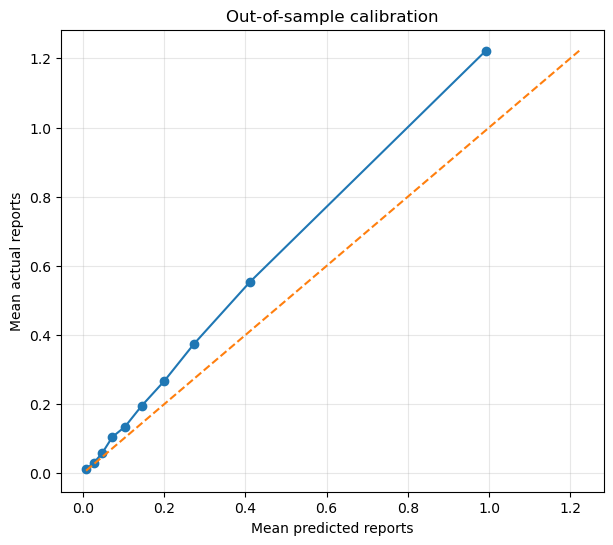

In [ ]:
cal = calibration_table(oos, bins=10)
display(cal.round(4))

plt.figure(figsize=(7, 6))
plt.plot(cal["mean_predicted"], cal["mean_actual"], marker="o")

lo = min(cal["mean_predicted"].min(), cal["mean_actual"].min())
hi = max(cal["mean_predicted"].max(), cal["mean_actual"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("Mean predicted reports")
plt.ylabel("Mean actual reports")
plt.title("Out-of-sample calibration")
plt.grid(alpha=0.3)
plt.show()


## 8. Inspect the biggest misses

Pearson residuals can become enormous when an ultra-sparse area has an almost-zero prediction and then receives a report. The table below keeps this visible without dumping dozens of diagnostic tables.


In [ ]:
largest_misses = (
    oos.assign(abs_pearson=lambda x: x["pearson_residual"].abs())
    .sort_values("abs_pearson", ascending=False)
)

display(
    largest_misses[
        [
            "area_name",
            "date",
            "reports",
            "predicted",
            "recent7_avg",
            "is_holiday",
            "pearson_residual",
        ]
    ].head(15)
)


,area_name,date,reports,predicted,recent7_avg,is_holiday,pearson_residual
24159,Προάστιο,2023-03-11,1,1.534156e-13,0.000000,False,1000000.000000
25503,Πόρτες,2023-11-15,1,7.130200e-13,0.000000,False,999999.999999
25475,Πόρτες,2023-10-18,1,8.573357e-13,0.000000,False,999999.999999
24358,Προάστιο,2023-09-26,1,1.028986e-12,0.000000,False,985814.500599
48129,Κρητικα,2024-09-24,16,7.569744e-02,0.000000,False,57.878839
64775,Αμπελόκηποι,2025-03-28,2,1.979656e-03,0.000000,False,44.906066
70030,Γουβα,2025-08-20,26,3.979681e-01,0.428571,False,40.583577
3593,Αμπελόκηποι,2023-11-05,1,6.702776e-04,0.000000,False,38.599480
90955,Ψαθόπυργος,2025-12-18,6,3.827071e-02,0.000000,False,30.474670
4856,Αραχωβίτικα,2023-04-22,4,1.983817e-02,0.142857,False,28.258552


## Current conclusion

The retained area-level forecasting model is a shared Poisson GLM with:

- area-specific baseline
- linear time trend
- weekday
- month
- Greek public-holiday indicator
- previous-7-day mean for the same area

The main remaining weakness is the set of ultra-sparse areas, where fixed area effects can produce near-zero expected counts. That should be treated as a future modeling question rather than adding arbitrary complexity here.

For now, this notebook is the compact source of truth for daily area-level point forecasting.


In [ ]:
actual_2026 = np.array([2, 5, 2, 10, 8, 2, 19])

future_dates = pd.date_range(
    "2026-01-01",
    "2026-01-07",
    freq="D"
)

greek_holidays_2026 = holidays.country_holidays(
    "GR",
    years=[2026]
)

trend_origin = panel["date"].min()


def forecast_week(formula):

    # Fit on all available data through 2025
    model = fit_area_poisson(
        panel,
        formula=formula
    )

    # Last 7 REAL observed days for each area
    history = {
        area: list(
            group.sort_values("date")["reports"].tail(7)
        )
        for area, group in panel.groupby("area_name")
    }

    forecasts = []

    for date in future_dates:

        future_day = pd.DataFrame({
            "area_name": list(history.keys())
        })

        future_day["date"] = date
        future_day["weekday"] = date.day_name()
        future_day["month"] = date.month
        future_day["is_holiday"] = (
            date.date() in greek_holidays_2026
        )

        future_day["trend_years"] = (
            (date - trend_origin).days / 365.25
        )

        future_day["recent7_avg"] = [
            np.mean(history[area])
            for area in future_day["area_name"]
        ]

        # Predict every area separately
        future_day["predicted"] = model.predict(
            future_day
        )

        # City-wide prediction = sum of area predictions
        forecasts.append(
            future_day["predicted"].sum()
        )

        # Recursive update:
        # after Dec 31 we don't know actual per-area counts,
        # so use each area's own prediction
        for area, pred in zip(
            future_day["area_name"],
            future_day["predicted"]
        ):
            history[area].append(pred)
            history[area] = history[area][-7:]

    return np.array(forecasts)


# ------------------------------------------------------------
# Forecast both models
# ------------------------------------------------------------

pred_no_trend = forecast_week(
    NO_TREND_FORMULA
)

pred_trend = forecast_week(
    AREA_FORMULA
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

comparison_2026 = pd.DataFrame({
    "date": future_dates,
    "actual": actual_2026,
    "no_trend": pred_no_trend,
    "with_trend": pred_trend,
})

comparison_2026["no_trend_abs_error"] = np.abs(
    comparison_2026["actual"]
    - comparison_2026["no_trend"]
)

comparison_2026["trend_abs_error"] = np.abs(
    comparison_2026["actual"]
    - comparison_2026["with_trend"]
)

display(comparison_2026.round(2))


def print_metrics(name, predictions):

    errors = actual_2026 - predictions

    print(f"\n{name}")
    print("-" * len(name))

    print(
        f"Predicted week total: "
        f"{predictions.sum():.2f}"
    )

    print(
        f"Actual week total:    "
        f"{actual_2026.sum()}"
    )

    print(
        f"MAE:                  "
        f"{np.mean(np.abs(errors)):.2f}"
    )

    print(
        f"RMSE:                 "
        f"{np.sqrt(np.mean(errors ** 2)):.2f}"
    )

    print(
        f"Total error:           "
        f"{predictions.sum() - actual_2026.sum():+.2f}"
    )


print_metrics(
    "NO-TREND MODEL",
    pred_no_trend
)

print_metrics(
    "TREND MODEL",
    pred_trend
)

NameError: name 'holidays' is not defined

In [ ]:
# ============================================================
# TRUE 2026 OUT-OF-SAMPLE TEST
# Proper rolling one-day-ahead evaluation:
# each prediction uses the REAL previous 7 days for that area
# ============================================================

import numpy as np
import pandas as pd
import holidays

from sklearn.metrics import mean_poisson_deviance
from src.area_mapping import map_requests_to_areas


# ------------------------------------------------------------
# 1. LOAD 2026 DATA
# ------------------------------------------------------------

df2026 = pd.read_csv(
    PROJECT_ROOT / "data" / "2026requests.csv"
)

# 'reported' contains date + hour + minute
df2026["reported"] = pd.to_datetime(
    df2026["reported"],
    errors="coerce"
)

df2026 = df2026.dropna(
    subset=["reported", "lat", "lng"]
).copy()

# If the 2026 file contains multiple issue types,
# keep only garbage reports.
if "issue" in df2026.columns:
    df2026 = df2026[
        df2026["issue"].eq("garbage")
    ].copy()

print("Raw 2026 garbage reports:", f"{len(df2026):,}")
print(
    "Raw timestamp range:",
    df2026["reported"].min(),
    "->",
    df2026["reported"].max()
)


# ------------------------------------------------------------
# 2. MAP 2026 COORDINATES TO AREAS
# ------------------------------------------------------------

areas_df = pd.read_csv(
    PROJECT_ROOT / "data" / "area_boundaries.csv"
)

mapped2026 = map_requests_to_areas(
    df2026,
    areas_df
)

# Convert timestamp to calendar day.
# Example:
# 2026-03-12 14:37:00 -> 2026-03-12 00:00:00
mapped2026["date"] = (
    mapped2026["reported"]
    .dt.normalize()
)

print("\n=== MAPPING ===")

print(
    f"Reports:   {len(mapped2026):,}"
)

print(
    f"Mapped:    "
    f"{mapped2026['area_name'].notna().sum():,}"
)

print(
    f"Unmapped:  "
    f"{mapped2026['area_name'].isna().sum():,}"
)

print(
    f"Mapped %:  "
    f"{100 * mapped2026['area_name'].notna().mean():.2f}%"
)


# ------------------------------------------------------------
# 3. CHECK WHETHER 2026 CONTAINS AREAS NOT SEEN IN TRAINING
# ------------------------------------------------------------

training_areas = sorted(
    panel["area_name"].unique()
)

new_areas = (
    set(mapped2026["area_name"].dropna().unique())
    - set(training_areas)
)

if new_areas:

    print("\nWARNING: unseen areas in 2026:")

    for area in sorted(new_areas):
        print(area)

else:
    print("\nNo unseen areas in 2026.")


# Fixed-effect model can only predict areas
# that existed in the training data.
mapped2026 = mapped2026[
    mapped2026["area_name"].isin(training_areas)
].copy()


# ------------------------------------------------------------
# 4. CREATE COMPLETE AREA x DAY GRID FOR 2026
#
# This is important:
# if an area had no reports on a day,
# that area-day must explicitly have reports = 0.
# ------------------------------------------------------------

start_2026 = mapped2026["date"].min()
end_2026 = mapped2026["date"].max()

dates2026 = pd.date_range(
    start=start_2026,
    end=end_2026,
    freq="D"
)

grid2026 = pd.MultiIndex.from_product(
    [
        training_areas,
        dates2026
    ],
    names=[
        "area_name",
        "date"
    ]
)

counts2026 = (
    mapped2026
    .groupby(
        ["area_name", "date"]
    )
    .size()
    .rename("reports")
    .reindex(
        grid2026,
        fill_value=0
    )
    .reset_index()
)

counts2026["reports"] = (
    counts2026["reports"]
    .astype(int)
)

print("\n=== 2026 PANEL ===")

print(
    "Period:",
    counts2026["date"].min().date(),
    "->",
    counts2026["date"].max().date()
)

print(
    f"Areas:     "
    f"{counts2026['area_name'].nunique()}"
)

print(
    f"Area-days: "
    f"{len(counts2026):,}"
)


# ------------------------------------------------------------
# 5. COMBINE REAL 2020-2025 HISTORY WITH REAL 2026 COUNTS
#
# THIS is what makes the test properly one-day-ahead.
#
# For example:
# prediction for March 15 uses actual March 8-14 counts.
#
# It NEVER uses March 15 itself or future observations.
# ------------------------------------------------------------

historical_actual = panel[
    [
        "area_name",
        "date",
        "reports"
    ]
].copy()

history = pd.concat(
    [
        historical_actual,
        counts2026
    ],
    ignore_index=True
)

history = (
    history
    .sort_values(
        ["area_name", "date"]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. CREATE REAL PREVIOUS-7-DAY AVERAGE
#
# shift(1) is crucial:
#
# today's reports are excluded.
# ------------------------------------------------------------

history["recent7_avg"] = (
    history
    .groupby("area_name")["reports"]
    .transform(
        lambda x:
        x.shift(1)
         .rolling(7)
         .mean()
    )
)


# ------------------------------------------------------------
# 7. CALENDAR FEATURES
# ------------------------------------------------------------

history["weekday"] = (
    history["date"]
    .dt.day_name()
)

history["month"] = (
    history["date"]
    .dt.month
)

greek_holidays = holidays.country_holidays(
    "GR",
    years=range(
        history["date"].dt.year.min(),
        history["date"].dt.year.max() + 1
    )
)

history["is_holiday"] = (
    history["date"]
    .dt.date
    .isin(greek_holidays)
)

trend_origin = panel["date"].min()

history["trend_years"] = (
    (history["date"] - trend_origin).dt.days
    / 365.25
)
# ------------------------------------------------------------
# 8. FIT MODEL USING ONLY 2020-2025
#
# Current selected version:
# NO TREND
# ------------------------------------------------------------

model2026 = fit_area_poisson(
    panel,
    formula=AREA_FORMULA
)


# ------------------------------------------------------------
# 9. 2026 TEST SET
# ------------------------------------------------------------

test2026 = (
    history[
        history["date"].dt.year == 2026
    ]
    .dropna(
        subset=["recent7_avg"]
    )
    .copy()
)

test2026["predicted"] = (
    model2026.predict(
        test2026
    )
)


# ------------------------------------------------------------
# 10. AREA-DAY METRICS
# ------------------------------------------------------------

actual = (
    test2026["reports"]
    .to_numpy()
)

pred = (
    test2026["predicted"]
    .to_numpy()
)

zero = actual == 0
active = actual > 0


mae = np.mean(
    np.abs(actual - pred)
)

rmse = np.sqrt(
    np.mean(
        (actual - pred) ** 2
    )
)

poisson_dev = (
    mean_poisson_deviance(
        actual,
        np.maximum(
            pred,
            1e-12
        )
    )
)

zero_mae = np.mean(
    np.abs(
        actual[zero]
        - pred[zero]
    )
)

active_mae = np.mean(
    np.abs(
        actual[active]
        - pred[active]
    )
)

mean_actual = actual.mean()
mean_predicted = pred.mean()

mean_error = np.mean(
    actual - pred
)

observed_zero_pct = (
    100 * zero.mean()
)

expected_zero_pct = (
    100
    * np.exp(-pred).mean()
)


print("\n" + "=" * 55)
print("2026 AREA-DAY OUT-OF-SAMPLE PERFORMANCE")
print("=" * 55)

print(
    f"Period:          "
    f"{test2026['date'].min().date()} "
    f"-> "
    f"{test2026['date'].max().date()}"
)

print(
    f"Area-days:       "
    f"{len(test2026):,}"
)

print()

print(
    f"MAE:             "
    f"{mae:.4f}"
)

print(
    f"RMSE:            "
    f"{rmse:.4f}"
)

print(
    f"Poisson deviance:"
    f"{poisson_dev:.4f}"
)

print()

print(
    f"Zero-day MAE:    "
    f"{zero_mae:.4f}"
)

print(
    f"Active-day MAE:  "
    f"{active_mae:.4f}"
)

print()

print(
    f"Mean actual:     "
    f"{mean_actual:.4f}"
)

print(
    f"Mean predicted:  "
    f"{mean_predicted:.4f}"
)

print(
    f"Mean error:      "
    f"{mean_error:+.4f}"
)

print()

print(
    f"Observed zeros:  "
    f"{observed_zero_pct:.2f}%"
)

print(
    f"Expected zeros:  "
    f"{expected_zero_pct:.2f}%"
)


# ------------------------------------------------------------
# 11. CITY-WIDE DAILY TOTALS
#
# These are simply the sum of all area predictions each day.
# ------------------------------------------------------------

daily2026 = (
    test2026
    .groupby(
        "date",
        as_index=False
    )
    .agg(
        actual=(
            "reports",
            "sum"
        ),
        predicted=(
            "predicted",
            "sum"
        )
    )
)

daily2026["error"] = (
    daily2026["actual"]
    - daily2026["predicted"]
)

daily2026["absolute_error"] = (
    daily2026["error"]
    .abs()
)


daily_mae = (
    daily2026[
        "absolute_error"
    ].mean()
)

daily_rmse = np.sqrt(
    np.mean(
        daily2026[
            "error"
        ] ** 2
    )
)


print("\n" + "=" * 55)
print("2026 CITY-WIDE DAILY PERFORMANCE")
print("=" * 55)

print(
    f"Actual total:     "
    f"{daily2026['actual'].sum():,.0f}"
)

print(
    f"Predicted total:  "
    f"{daily2026['predicted'].sum():,.2f}"
)

print(
    f"Total difference: "
    f"{daily2026['predicted'].sum() - daily2026['actual'].sum():+,.2f}"
)

print()

print(
    f"Daily MAE:        "
    f"{daily_mae:.2f}"
)

print(
    f"Daily RMSE:       "
    f"{daily_rmse:.2f}"
)


# ------------------------------------------------------------
# 12. DAILY RESULTS TABLE
# ------------------------------------------------------------

display(
    daily2026.round({
        "predicted": 2,
        "error": 2,
        "absolute_error": 2
    })
)

Raw 2026 garbage reports: 3,795
Raw timestamp range: 2026-01-01 01:56:13 -> 2026-06-08 13:17:34

=== MAPPING ===
Reports:   3,795
Mapped:    3,765
Unmapped:  30
Mapped %:  99.21%

No unseen areas in 2026.

=== 2026 PANEL ===
Period: 2026-01-01 -> 2026-06-08
Areas:     84
Area-days: 13,356


C:\Users\User\Desktop\requests 2\src\area_mapping.py:115: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([mapped, invalid], ignore_index=True, sort=False)



2026 AREA-DAY OUT-OF-SAMPLE PERFORMANCE
Period:          2026-01-01 -> 2026-06-08
Area-days:       13,356

MAE:             0.3632
RMSE:            0.6900
Poisson deviance:0.7558

Zero-day MAE:    0.2153
Active-day MAE:  1.0136

Mean actual:     0.2819
Mean predicted:  0.2907
Mean error:      -0.0088

Observed zeros:  81.47%
Expected zeros:  78.82%

2026 CITY-WIDE DAILY PERFORMANCE
Actual total:     3,765
Predicted total:  3,882.93
Total difference: +117.93

Daily MAE:        6.48
Daily RMSE:       9.04


,date,actual,predicted,error,absolute_error
0,2026-01-01,2,5.15,-3.15,3.15
1,2026-01-02,5,17.45,-12.45,12.45
2,2026-01-03,2,6.51,-4.51,4.51
3,2026-01-04,10,6.83,3.17,3.17
4,2026-01-05,8,24.57,-16.57,16.57
...,...,...,...,...,...
154,2026-06-04,38,41.29,-3.29,3.29
155,2026-06-05,53,38.35,14.65,14.65
156,2026-06-06,13,14.58,-1.58,1.58
157,2026-06-07,23,15.35,7.65,7.65


NameError: name 'daily2026' is not defined